# 10. 卷积神经网络（基础篇）


CNN - Convolutional Neural Network

之前的算是全连接的神经网络，但是不需要每个像素都和后面相关. 且没保存原本的空间结构

0、前一部分叫做Feature Extraction，后一部分叫做classification

1、每一个卷积核它的通道数量要求和输入通道是一样的。这种卷积核的总数有多少个和你输出通道的数量是一样的。

2、卷积(convolution)后，C(Channels)变，W(width)和H(Height)可变可不变，取决于是否padding。subsampling(或pooling)后，C不变，W和H变。

3、卷积层：保留图像的空间信息。

4、卷积层要求输入输出是四维张量(B,C,W,H)，全连接层的输入与输出都是二维张量(B,Input_feature)。

5、卷积(线性 变换)，激活函数(非线性变换)，池化；这个过程若干次后，view打平，进入全连接层~

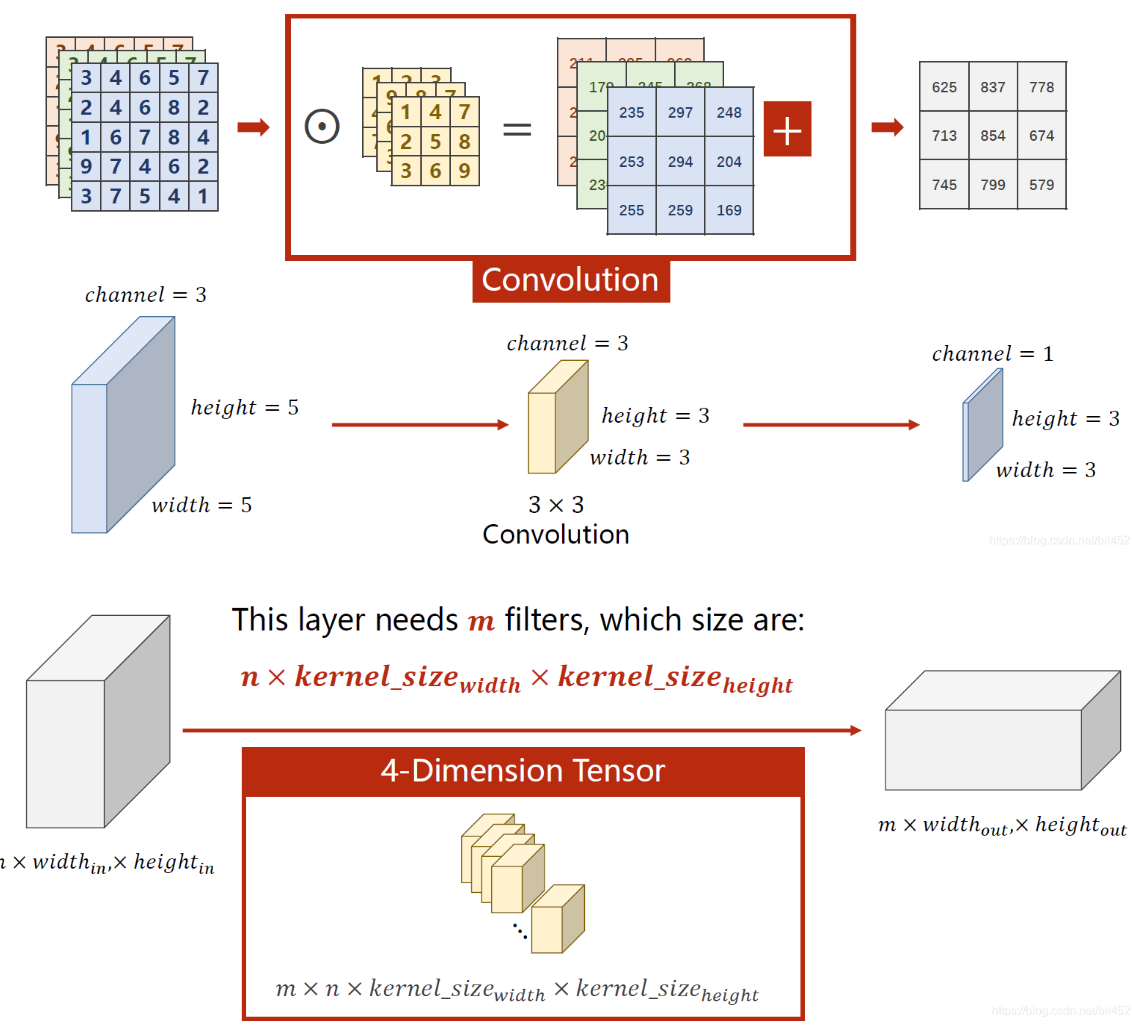


关于代码：

1、torch.nn.Conv2d(1,10,kernel_size=3,stride=2,bias=False)

1是指输入的Channel，灰色图像是1维的；10是指输出的Channel，也可以说第一个卷积层需要10个卷积核；kernel_size=3,卷积核大小是3x3；stride=2进行卷积运算时的步长，默认为1；bias=False卷积运算是否需要偏置bias，默认为False。padding = 0，卷积操作是否补0。

2、self.fc = torch.nn.Linear(320, 10)，这个320获取的方式，可以通过x = x.view(batch_size, -1) # print(x.shape)可得到(64,320),64指的是batch，320就是指要进行全连接操作时，输入的特征维度。

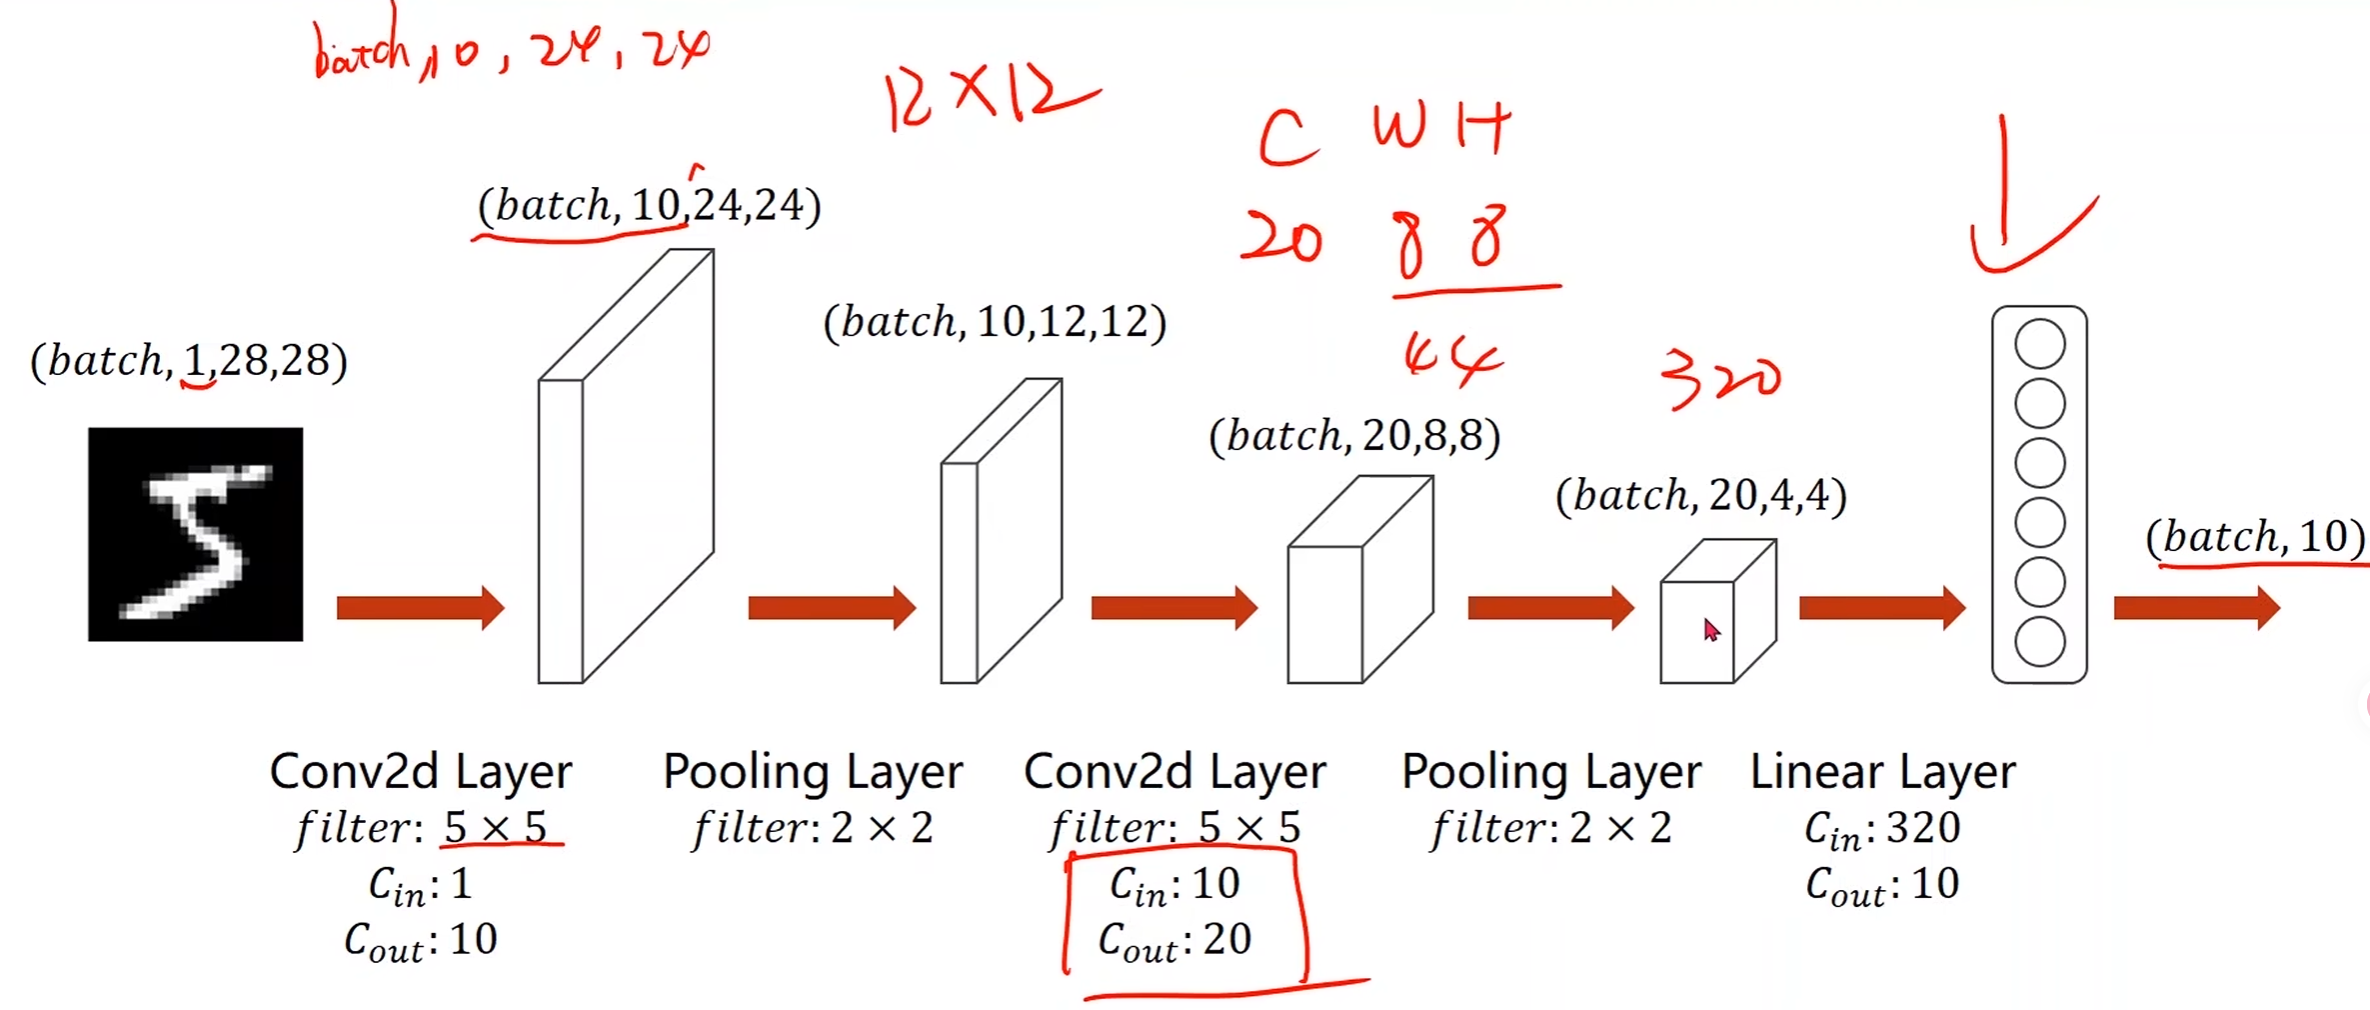

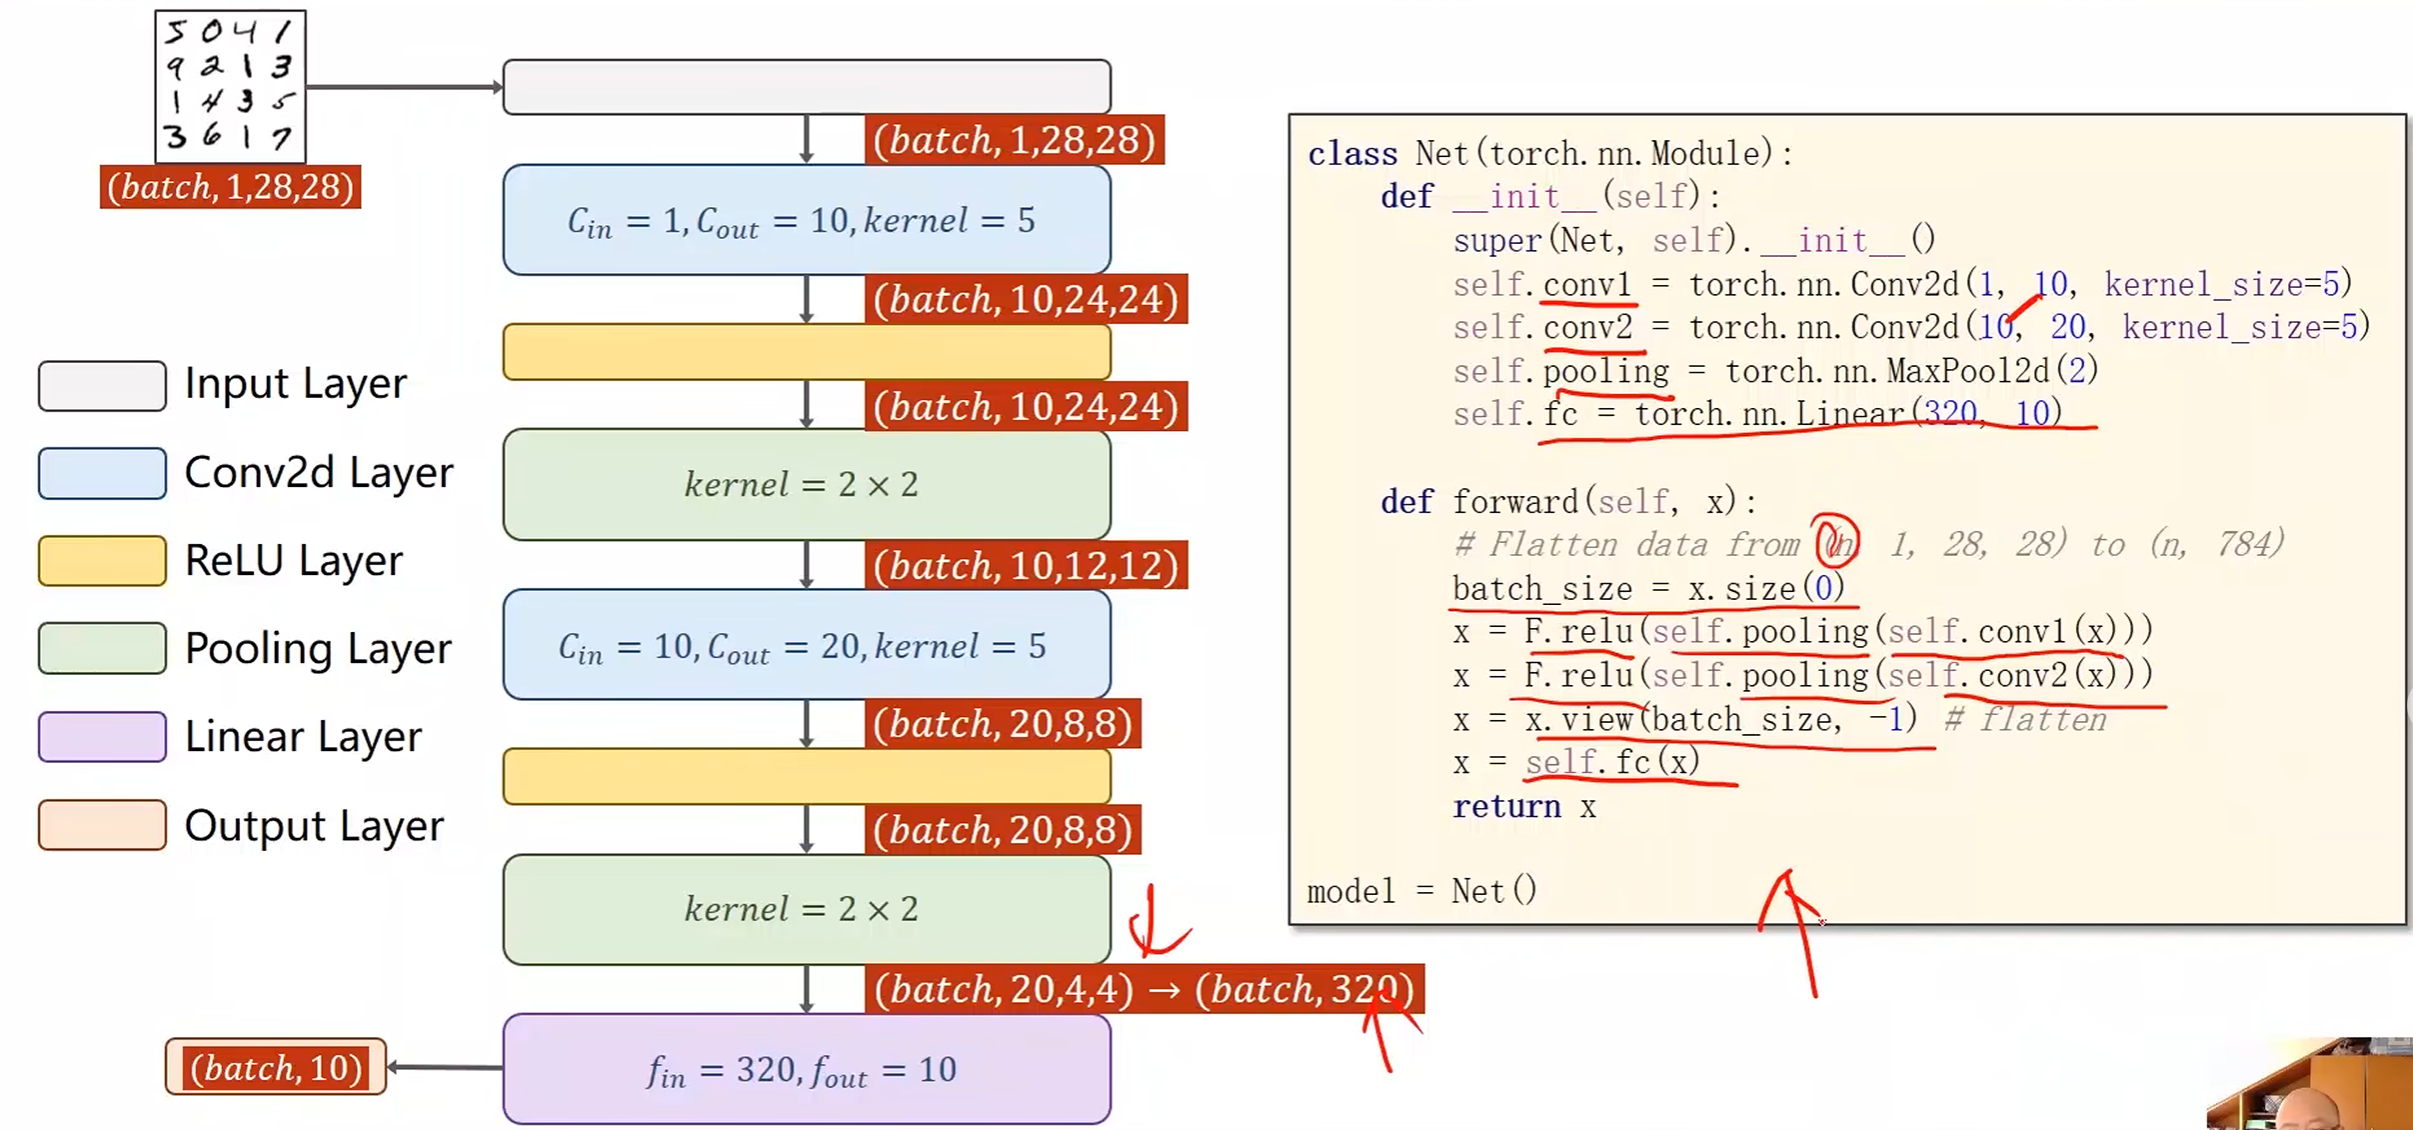

In [1]:
import torch
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch.optim as optim
 
# prepare dataset
batch_size = 64
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])

train_dataset = datasets.MNIST(root='../dataset/mnist/', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_dataset = datasets.MNIST(root='../dataset/mnist/', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)
 
# design model using class
class Net(torch.nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = torch.nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = torch.nn.Conv2d(10, 20, kernel_size=5)
        self.pooling = torch.nn.MaxPool2d(2)
        self.fc = torch.nn.Linear(320, 10)
    def forward(self, x):
        # flatten data from (n,1,28,28) to (n, 784)
        batch_size = x.size(0)
        x = F.relu(self.pooling(self.conv1(x)))
        x = F.relu(self.pooling(self.conv2(x)))
        x = x.view(batch_size, -1) # -1 此处自动算出的是320
        x = self.fc(x)
        return x
model = Net()
 
# construct loss and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)
 
# training cycle forward, backward, update
def train(epoch):
    running_loss = 0.0
    for batch_idx, data in enumerate(train_loader, 0):
        inputs, target = data
        optimizer.zero_grad()
 
        outputs = model(inputs)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
 
        running_loss += loss.item()
        if batch_idx % 300 == 299:
            print('[%d, %5d] loss: %.3f' % (epoch+1, batch_idx+1, running_loss/300))
            running_loss = 0.0
 
 
def test():
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_loader:
            images, labels = data
            outputs = model(images)
            _, predicted = torch.max(outputs.data, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print('accuracy on test set: %d %% ' % (100*correct/total))
 
 
if __name__ == '__main__':
    for epoch in range(10):
        train(epoch)
        test()

[1,   300] loss: 0.614
[1,   600] loss: 0.208
[1,   900] loss: 0.147
accuracy on test set: 95 % 
[2,   300] loss: 0.117
[2,   600] loss: 0.108
[2,   900] loss: 0.089
accuracy on test set: 97 % 
[3,   300] loss: 0.086
[3,   600] loss: 0.080
[3,   900] loss: 0.070
accuracy on test set: 97 % 
[4,   300] loss: 0.062
[4,   600] loss: 0.072
[4,   900] loss: 0.062
accuracy on test set: 98 % 
[5,   300] loss: 0.058
[5,   600] loss: 0.057
[5,   900] loss: 0.055
accuracy on test set: 98 % 
[6,   300] loss: 0.051
[6,   600] loss: 0.049
[6,   900] loss: 0.053
accuracy on test set: 98 % 
[7,   300] loss: 0.048
[7,   600] loss: 0.046
[7,   900] loss: 0.046
accuracy on test set: 98 % 
[8,   300] loss: 0.048
[8,   600] loss: 0.039
[8,   900] loss: 0.043
accuracy on test set: 98 % 
[9,   300] loss: 0.040
[9,   600] loss: 0.038
[9,   900] loss: 0.041
accuracy on test set: 98 % 
[10,   300] loss: 0.035
[10,   600] loss: 0.040
[10,   900] loss: 0.036
accuracy on test set: 98 % 


用gpu训：

首先，model定好了 在下面把其所有权重、模块什么的陡增移到device上

train和test时候，把input和target的数据都放device上

[1,   300] loss: 0.651
[1,   600] loss: 0.214
[1,   900] loss: 0.153
accuracy on test set: 97 % 
[2,   300] loss: 0.118
[2,   600] loss: 0.100
[2,   900] loss: 0.095
accuracy on test set: 97 % 
[3,   300] loss: 0.082
[3,   600] loss: 0.076
[3,   900] loss: 0.078
accuracy on test set: 97 % 
[4,   300] loss: 0.069
[4,   600] loss: 0.066
[4,   900] loss: 0.062
accuracy on test set: 97 % 
[5,   300] loss: 0.060
[5,   600] loss: 0.053
[5,   900] loss: 0.060
accuracy on test set: 98 % 
[6,   300] loss: 0.050
[6,   600] loss: 0.054
[6,   900] loss: 0.047
accuracy on test set: 98 % 
[7,   300] loss: 0.041
[7,   600] loss: 0.048
[7,   900] loss: 0.048
accuracy on test set: 98 % 
[8,   300] loss: 0.041
[8,   600] loss: 0.043
[8,   900] loss: 0.041
accuracy on test set: 98 % 
[9,   300] loss: 0.037
[9,   600] loss: 0.039
[9,   900] loss: 0.038
accuracy on test set: 98 % 
[10,   300] loss: 0.039
[10,   600] loss: 0.033
[10,   900] loss: 0.035
accuracy on test set: 98 % 


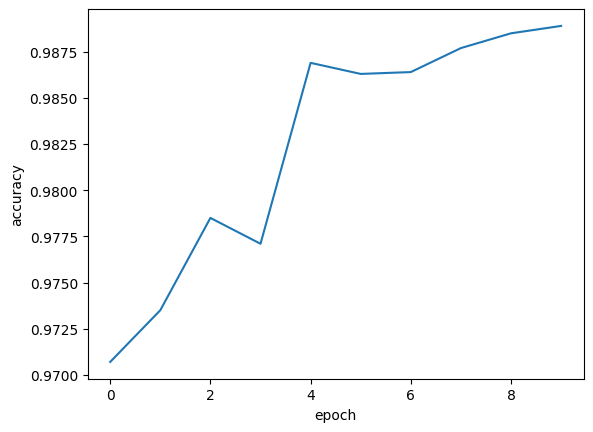

In [2]:
import torch
from torchvision import transforms
from torchvision import datasets
from torch.utils.data import DataLoader
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
 
# prepare dataset
 
batch_size = 64
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
 
train_dataset = datasets.MNIST(root='../dataset/mnist/', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, shuffle=True, batch_size=batch_size)
test_dataset = datasets.MNIST(root='../dataset/mnist/', train=False, download=True, transform=transform)
test_loader = DataLoader(test_dataset, shuffle=False, batch_size=batch_size)
 
# design model using class
 
 
class Net(torch.nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = torch.nn.Conv2d(1, 10, kernel_size=5)
        self.conv2 = torch.nn.Conv2d(10, 20, kernel_size=5)
        self.pooling = torch.nn.MaxPool2d(2)
        self.fc = torch.nn.Linear(320, 10)
 
 
    def forward(self, x):
        # flatten data from (n,1,28,28) to (n, 784)
        
        batch_size = x.size(0)
        x = F.relu(self.pooling(self.conv1(x)))
        x = F.relu(self.pooling(self.conv2(x)))
        x = x.view(batch_size, -1) # -1 此处自动算出的是320
        # print("x.shape",x.shape)
        x = self.fc(x)
 
        return x
 
 
model = Net()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
 
# construct loss and optimizer
criterion = torch.nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.5)
 
# training cycle forward, backward, update
 
 
def train(epoch):
    running_loss = 0.0
    for batch_idx, data in enumerate(train_loader, 0):
        inputs, target = data
        inputs, target = inputs.to(device), target.to(device)
        optimizer.zero_grad()
 
        outputs = model(inputs)
        loss = criterion(outputs, target)
        loss.backward()
        optimizer.step()
 
        running_loss += loss.item()
        if batch_idx % 300 == 299:
            print('[%d, %5d] loss: %.3f' % (epoch+1, batch_idx+1, running_loss/300))
            running_loss = 0.0
 
 
def test():
    correct = 0
    total = 0
    with torch.no_grad():
        for data in test_loader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    print('accuracy on test set: %d %% ' % (100*correct/total))
    return correct/total
 
 
if __name__ == '__main__':
    epoch_list = []
    acc_list = []
    
    for epoch in range(10):
        train(epoch)
        acc = test()
        epoch_list.append(epoch)
        acc_list.append(acc)
    
    plt.plot(epoch_list,acc_list)
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.show()
 
    